# 03 Resultados Finales

Este notebook consolida la etapa final del proyecto:
- carga resultados de ACO y GA
- compara ambos metodos
- selecciona la mejor solucion
- expande el tour TSP a una ruta real sobre el grafo
- genera visualizaciones y GIF
- exporta artefactos listos para entrega y para la web


In [37]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

ROOT

WindowsPath('C:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/2. optimizacion_combinatoria')

In [38]:
import json
from html import escape as html_escape
import pandas as pd
from IPython.display import HTML, Image, SVG, Markdown, display


from src.core_paths import VIS_OUTPUT_DIR, WEB_OUTPUT_DIR
from src.core_resultados import (
    build_comparison,
    expand_best_tour,
    export_final_bundle,
    export_visual_artifacts,
    generate_solution_gif,
    load_method_results,
    pick_best_result,
)


In [39]:
def load_json(path):
    with Path(path).open('r', encoding='utf-8') as handle:
        return json.load(handle)

def show_table(title, df, columns=None, sort_by=None, ascending=True, precision=4):
    table = df.copy()
    if columns is not None:
        table = table.reindex(columns=columns)
    if sort_by is not None:
        table = table.sort_values(sort_by, ascending=ascending).reset_index(drop=True)
    display(Markdown(f'### {title}'))
    display(table.fillna('-').style.format(precision=precision))


## 1. Cargar resultados de optimizacion

Se recuperan los resultados guardados por el notebook `02_optimizacion.ipynb`.

In [40]:
aco_result, ga_result = load_method_results()
print('Costo ACO:', aco_result['mejor_costo_tour'])
print('Costo GA:', ga_result['mejor_costo_tour'])

Costo ACO: 4022.039333
Costo GA: 3975.266333


## 2. Comparacion de metodos

Se construye una comparacion numerica entre ACO y GA y se identifica automaticamente el mejor metodo.

In [41]:
comparison = build_comparison(aco_result, ga_result)
best_method, best_result = pick_best_result(aco_result, ga_result)
comparison

{'mejor_metodo': 'GA',
 'costo_aco': 4022.039333,
 'costo_ga': 3975.266333,
 'mejor_costo': 3975.266333,
 'diferencia_absoluta': 46.773,
 'diferencia_relativa_pct': 1.1629}

In [42]:
pd.DataFrame([
    {'metodo': 'ACO', 'mejor_costo': aco_result['mejor_costo_tour']},
    {'metodo': 'GA', 'mejor_costo': ga_result['mejor_costo_tour']},
]).sort_values('mejor_costo').reset_index(drop=True)

,metodo,mejor_costo
0,GA,3975.266333
1,ACO,4022.039333


## 3. Mejor solucion y tour expandido

El mejor tour sobre la matriz TSP se expande a la ruta real sobre el grafo usando la matriz de siguiente salto.

In [43]:
expanded = expand_best_tour(best_result)
print('Metodo ganador:', best_method)
print('Costo mejor tour:', best_result['mejor_costo_tour'])
print('Saltos TSP:', expanded['n_saltos_tsp'])
print('Saltos reales:', expanded['n_saltos_reales'])

Metodo ganador: GA
Costo mejor tour: 3975.266333
Saltos TSP: 96
Saltos reales: 100


In [44]:
pd.DataFrame(expanded['tramos_expandidos']).head()

,origen_indice,destino_indice,ruta_indices,costo_tramo,ruta_nombres
0,0,39,"[0, 39]",32.459667,"[Bourg-en-Bresse, Lons-le-Saunier]"
1,39,25,"[39, 25]",35.445667,"[Lons-le-Saunier, Besançon]"
2,25,70,"[25, 70]",21.635667,"[Besançon, Vesoul]"
3,70,90,"[70, 90]",25.318333,"[Vesoul, Belfort]"
4,90,68,"[90, 68]",28.418333,"[Belfort, Colmar]"


## 4. Visualizaciones finales

Se genera una figura SVG lista para el reporte final, con la mejor ruta dibujada sobre un mapa estilizado de Francia, y una vista HTML interactiva para inspeccion visual adicional.


In [45]:
import importlib
import src.core_resultados as core_resultados

importlib.reload(core_resultados)
visuals = core_resultados.export_visual_artifacts(best_result, best_method, expanded_tour=expanded)
visuals


{'route_svg_path': WindowsPath('C:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/2. optimizacion_combinatoria/outputs/visualizaciones/visualizacion_mejor_solucion.svg'),
 'route_projection_svg_path': WindowsPath('C:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/2. optimizacion_combinatoria/outputs/visualizaciones/visualizacion_mejor_solucion_proyeccion.svg'),
 'route_map_html_path': WindowsPath('C:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/2. optimizacion_combinatoria/outputs/visualizaciones/visualizacion_mejor_solucion_mapa.html'),
 'history_svg_path': WindowsPath('C:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/2. optimizacion_combinatoria/outputs/visualizaciones/convergencia_ga.svg')}

### Mapa interactivo de la mejor ruta

C:\Users\CARLOS\AppData\Roaming\Python\Python313\site-packages\IPython\core\display.py:475: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


### Figura estatica alternativa

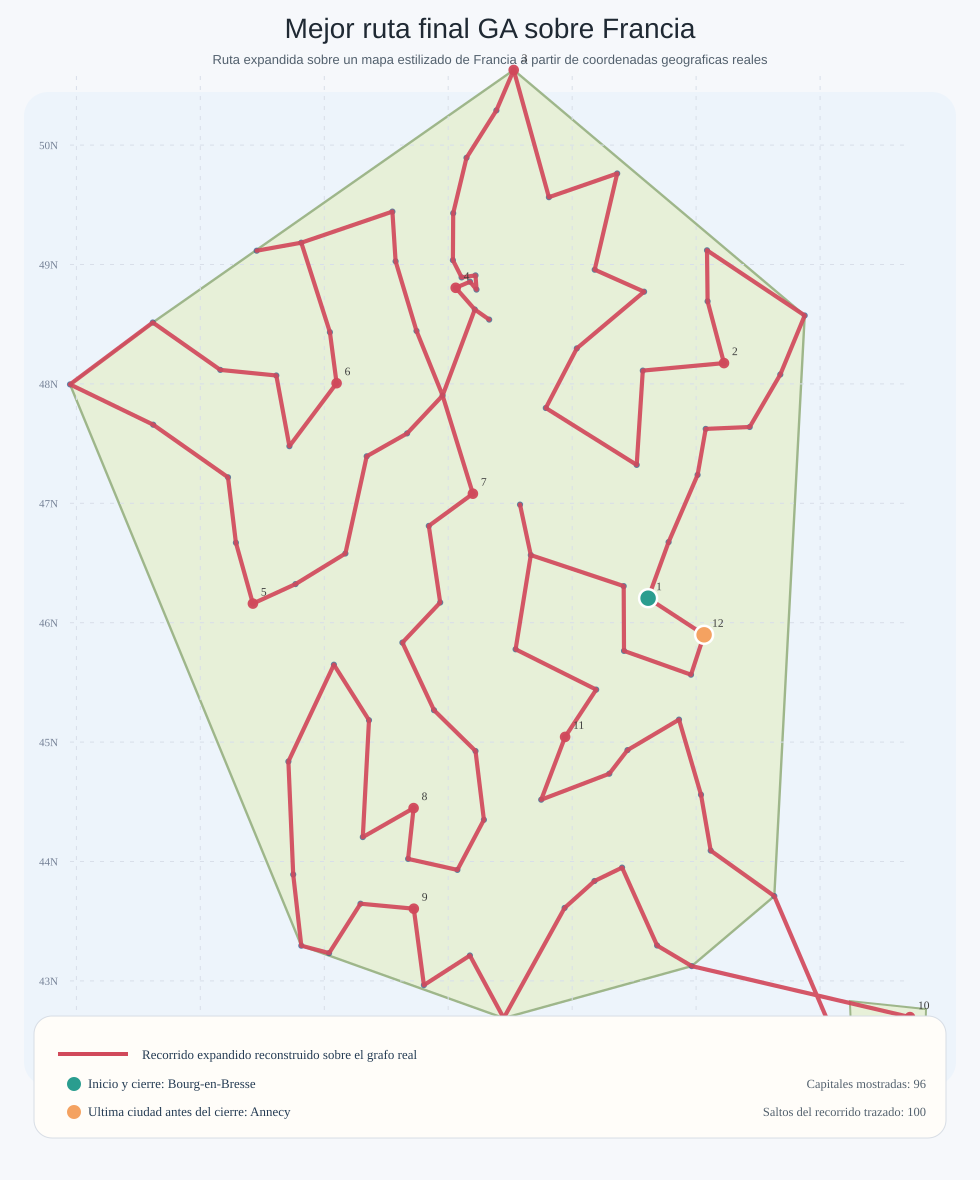

### Convergencia del metodo ganador

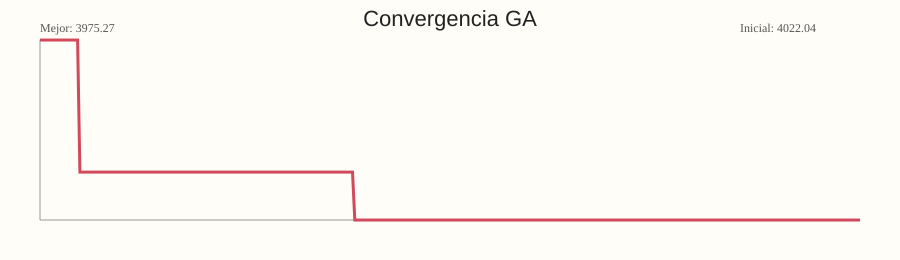

In [46]:
display(Markdown('### Mapa interactivo de la mejor ruta'))
map_html = visuals['route_map_html_path'].read_text(encoding='utf-8')
iframe_html = f'''<iframe srcdoc="{html_escape(map_html, quote=True)}" width="100%" height="760" style="border: 0; border-radius: 18px;"></iframe>'''
display(HTML(iframe_html))

display(Markdown('### Figura estatica alternativa'))
display(SVG(filename=str(visuals['route_svg_path'])))

display(Markdown('### Convergencia del metodo ganador'))
display(SVG(filename=str(visuals['history_svg_path'])))


## 5. GIF de la mejor solucion

La ruta final se anima para facilitar la comunicacion del resultado en la entrega y en la web.

In [47]:
gif_info = generate_solution_gif(best_method, best_result)
gif_info['gif_summary']

{'metodo_ganador': 'GA',
 'mejor_costo_tour': 3975.266333,
 'frames': 104,
 'archivo_gif': 'C:\\Carlos\\Uni\\Algortimos\\trabajos\\trabajo_1\\trabajo_carlos\\2. optimizacion_combinatoria\\outputs\\visualizaciones\\mejor_solucion_combinatoria.gif',
 'formula_peso': 'peajes(euros) + gasolina(euros) + (tiempo(min)/60) * 12.02'}

### GIF de la mejor solucion

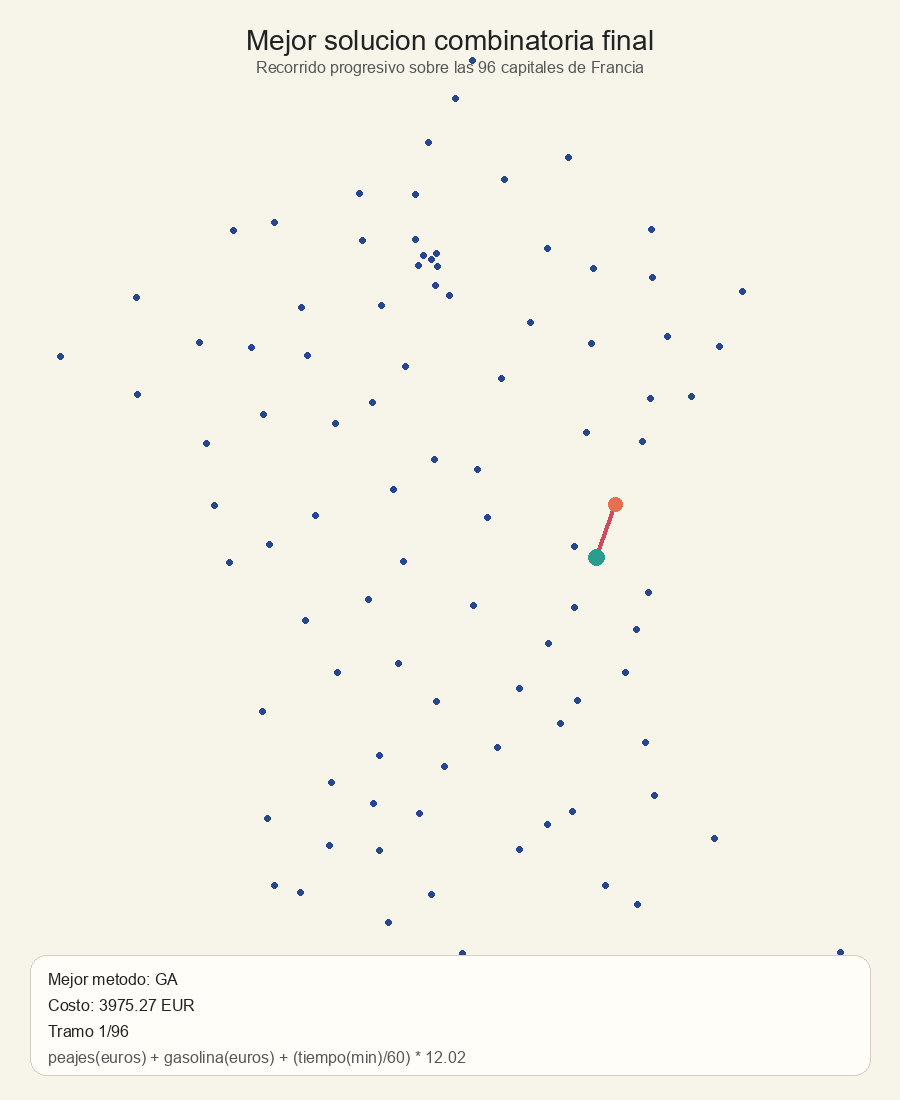

,metodo_ganador,mejor_costo_tour,frames,archivo_gif,formula_peso
0,GA,3975.266333,104,C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\tr...,peajes(euros) + gasolina(euros) + (tiempo(min)...


In [48]:
display(Markdown('### GIF de la mejor solucion'))
display(Image(filename=str(gif_info['gif_path'])))
pd.DataFrame([gif_info['gif_summary']])

## 6. Bundle final para la web

Se exportan archivos JSON finales pensados para consumo directo desde una aplicacion web, sin recalcular el pipeline.

In [49]:
final_bundle = export_final_bundle(best_method, best_result, expanded, comparison)
final_bundle['web_summary']

{'metodo_ganador': 'GA',
 'mejor_costo_tour': 3975.266333,
 'n_ciudades': 96,
 'n_saltos_reales': 100,
 'formula_peso': 'peajes(euros) + gasolina(euros) + (tiempo(min)/60) * 12.02'}

In [50]:
comparison_json = load_json(final_bundle['comparison_path'])
best_result_json = load_json(final_bundle['best_result_path'])
expanded_route_json = load_json(final_bundle['expanded_route_path'])
web_summary_json = load_json(final_bundle['web_summary_path'])

In [51]:
df_comparacion_json = pd.json_normalize(comparison_json)
df_resumen_web_json = pd.json_normalize(web_summary_json)
df_mejor_resultado_json = pd.json_normalize({
    'metodo_ganador': best_method,
    'mejor_costo_tour': best_result_json.get('mejor_costo_tour'),
    'shape_matriz': best_result_json.get('shape_matriz'),
    'formula_peso': best_result_json.get('formula_peso'),
    'tarifa_vendedor_eur_h': best_result_json.get('tarifa_vendedor_eur_h'),
    'salario_referencia': best_result_json.get('salario_referencia'),
    'n_ciudades_tour': len(best_result_json.get('mejor_tour_indices_sin_cierre', [])),
    'n_puntos_historial': len(best_result_json.get('historial_mejor_costo', [])),
    'inicio_tour_nombres': ', '.join(best_result_json.get('mejor_tour_nombres', [])[:8]),
})

show_table('Resumen web', df_resumen_web_json)
show_table('Comparacion de metodos', df_comparacion_json)
show_table('Mejor resultado', df_mejor_resultado_json)

### Resumen web

,metodo_ganador,mejor_costo_tour,n_ciudades,n_saltos_reales,formula_peso
0,GA,3975.2663,96,100,peajes(euros) + gasolina(euros) + (tiempo(min)/60) * 12.02


### Comparacion de metodos

,mejor_metodo,costo_aco,costo_ga,mejor_costo,diferencia_absoluta,diferencia_relativa_pct
0,GA,4022.0393,3975.2663,3975.2663,46.7730,1.1629


### Mejor resultado

,metodo_ganador,mejor_costo_tour,shape_matriz,formula_peso,tarifa_vendedor_eur_h,salario_referencia,n_ciudades_tour,n_puntos_historial,inicio_tour_nombres
0,GA,3975.2663,"[96, 96]",peajes(euros) + gasolina(euros) + (tiempo(min)/60) * 12.02,12.0200,SMIC Francia 2026,96,350,"Bourg-en-Bresse, Lons-le-Saunier, Besançon, Vesoul, Belfort, Colmar, Strasbourg, Metz"


In [52]:
df_tramos_expandidos = pd.DataFrame(expanded_route_json['tramos_expandidos'])
df_resumen_ruta_expandida = pd.DataFrame([{
    'saltos_tsp': expanded_route_json.get('n_saltos_tsp'),
    'saltos_reales': expanded_route_json.get('n_saltos_reales'),
    'costo_total_tour': expanded_route_json.get('costo_total_tour'),
    'n_tramos_expandidos': len(expanded_route_json.get('tramos_expandidos', [])),
    'inicio_ruta': expanded_route_json.get('recorrido_real_nombres', [None])[0],
    'fin_ruta': expanded_route_json.get('recorrido_real_nombres', [None])[-1],
}])

show_table('Resumen de la ruta expandida', df_resumen_ruta_expandida)
show_table('Ruta expandida por tramos (primeros 20)', df_tramos_expandidos.head(20))

### Resumen de la ruta expandida

,saltos_tsp,saltos_reales,costo_total_tour,n_tramos_expandidos,inicio_ruta,fin_ruta
0,96,100,3975.2663,96,Bourg-en-Bresse,Bourg-en-Bresse


### Ruta expandida por tramos (primeros 20)

,origen_indice,destino_indice,ruta_indices,costo_tramo,ruta_nombres
0,0,39,"[0, 39]",32.4597,"['Bourg-en-Bresse', 'Lons-le-Saunier']"
1,39,25,"[39, 25]",35.4457,"['Lons-le-Saunier', 'Besançon']"
2,25,70,"[25, 70]",21.6357,"['Besançon', 'Vesoul']"
3,70,90,"[70, 90]",25.3183,"['Vesoul', 'Belfort']"
4,90,68,"[90, 68]",28.4183,"['Belfort', 'Colmar']"
5,68,67,"[68, 67]",26.6993,"['Colmar', 'Strasbourg']"
6,67,57,"[67, 57]",60.7730,"['Strasbourg', 'Metz']"
7,57,54,"[57, 54]",21.6357,"['Metz', 'Nancy']"
8,54,88,"[54, 88]",29.0010,"['Nancy', 'Épinal']"
9,88,52,"[88, 52]",49.7937,"['Épinal', 'Chaumont']"


In [53]:
show_table('Artefactos finales generados', pd.DataFrame([
    {
        'nombre': 'comparacion_metodos.json',
        'ruta': str(final_bundle['comparison_path']),
        'tipo': 'JSON',
        'proposito': 'Comparacion consolidada entre ACO y GA para consumo final y web.',
    },
    {
        'nombre': 'mejor_resultado.json',
        'ruta': str(final_bundle['best_result_path']),
        'tipo': 'JSON',
        'proposito': 'Resultado completo del metodo ganador con tour, costo e historial.',
    },
    {
        'nombre': 'mejor_ruta_expandida.json',
        'ruta': str(final_bundle['expanded_route_path']),
        'tipo': 'JSON',
        'proposito': 'Ruta real expandida sobre el grafo a partir del tour TSP ganador.',
    },
    {
        'nombre': 'resumen_web.json',
        'ruta': str(final_bundle['web_summary_path']),
        'tipo': 'JSON',
        'proposito': 'Resumen compacto listo para alimentar una interfaz web o demo.',
    },
    {
        'nombre': 'visualizacion_mejor_solucion.svg',
        'ruta': str(visuals['route_svg_path']),
        'tipo': 'SVG',
        'proposito': 'Figura vectorial principal para el reporte final, con la ruta sobre un mapa estilizado de Francia.',
    },
    {
        'nombre': 'visualizacion_mejor_solucion_mapa.html',
        'ruta': str(visuals['route_map_html_path']),
        'tipo': 'HTML',
        'proposito': 'Vista interactiva del recorrido final sobre mapa base para inspeccion y capturas.',
    },
    {
        'nombre': 'visualizacion_mejor_solucion_proyeccion.svg',
        'ruta': str(visuals['route_projection_svg_path']),
        'tipo': 'SVG',
        'proposito': 'Version alternativa en proyeccion longitud-latitud de la mejor ruta encontrada.',
    },
    {
        'nombre': 'convergencia.svg',
        'ruta': str(visuals['history_svg_path']),
        'tipo': 'SVG',
        'proposito': 'Grafica de convergencia del metodo ganador durante la optimizacion.',
    },
    {
        'nombre': 'mejor_solucion_combinatoria.gif',
        'ruta': str(gif_info['gif_path']),
        'tipo': 'GIF',
        'proposito': 'Animacion progresiva del recorrido final para entrega y presentacion.',
    },
]), columns=['nombre', 'ruta', 'tipo', 'proposito'])


### Artefactos finales generados

,nombre,ruta,tipo,proposito
0,comparacion_metodos.json,C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\2. optimizacion_combinatoria\outputs\web\comparacion_metodos.json,JSON,Comparacion consolidada entre ACO y GA para consumo final y web.
1,mejor_resultado.json,C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\2. optimizacion_combinatoria\outputs\web\mejor_resultado.json,JSON,"Resultado completo del metodo ganador con tour, costo e historial."
2,mejor_ruta_expandida.json,C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\2. optimizacion_combinatoria\outputs\web\mejor_ruta_expandida.json,JSON,Ruta real expandida sobre el grafo a partir del tour TSP ganador.
3,resumen_web.json,C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\2. optimizacion_combinatoria\outputs\web\resumen_web.json,JSON,Resumen compacto listo para alimentar una interfaz web o demo.
4,visualizacion_mejor_solucion.svg,C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\2. optimizacion_combinatoria\outputs\visualizaciones\visualizacion_mejor_solucion.svg,SVG,"Figura vectorial principal para el reporte final, con la ruta sobre un mapa estilizado de Francia."
5,visualizacion_mejor_solucion_mapa.html,C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\2. optimizacion_combinatoria\outputs\visualizaciones\visualizacion_mejor_solucion_mapa.html,HTML,Vista interactiva del recorrido final sobre mapa base para inspeccion y capturas.
6,visualizacion_mejor_solucion_proyeccion.svg,C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\2. optimizacion_combinatoria\outputs\visualizaciones\visualizacion_mejor_solucion_proyeccion.svg,SVG,Version alternativa en proyeccion longitud-latitud de la mejor ruta encontrada.
7,convergencia.svg,C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\2. optimizacion_combinatoria\outputs\visualizaciones\convergencia_ga.svg,SVG,Grafica de convergencia del metodo ganador durante la optimizacion.
8,mejor_solucion_combinatoria.gif,C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\2. optimizacion_combinatoria\outputs\visualizaciones\mejor_solucion_combinatoria.gif,GIF,Animacion progresiva del recorrido final para entrega y presentacion.


## 7. Salida final

Al terminar este notebook quedan listos los artefactos finales en:
- `outputs/visualizaciones`
- `outputs/web`

Estos archivos pueden alimentar directamente la entrega escrita, una demo o una web.

In [54]:
print('Visualizaciones:', VIS_OUTPUT_DIR)
print('Bundle final web:', WEB_OUTPUT_DIR)

Visualizaciones: C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\2. optimizacion_combinatoria\outputs\visualizaciones
Bundle final web: C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\2. optimizacion_combinatoria\outputs\web
